# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [2]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [4]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [6]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", users.shape)

plans (2, 8)
users (4000, 8)
usage (4000, 8)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [11]:
# cantidad de nulos para users

print(users.isna().sum())
print(users.isna().mean())


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [12]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())


id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?

Para el dataset "users", el 100% de los nulos se encuentran concentrados en churn_date y city con una proporcion de 88,35% y 11.72% de faltantes correspondientemente. Para "usage", los nulos se encuentran concentrados entre  date con un 0.125%, duration con 55.19% y length con 44.74%.

- Indica qué harías: ¿imputar, eliminar, ignorar?

Se recomienda ignorar o borrar las columnas churn_date, duration y length, pues tienen una alta proporcion de nulos y para city, se recomienda estrategias de imputacion con la mediana, en el caso de date, es ncesario revisar formato para ambos datasets.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [13]:
# explorar columnas numéricas de users
users[['user_id', 'age']].describe()


,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` muestra la secuencia entre 10000 hasta 13999 sin problemas.
- La columna `age` contiene un sentinel de -999, muestra la edad maxima valida de 79 años.

In [14]:
# Cantidad de valores -999
cantidad_999 = (users['age'] == -999).sum()
print(f'Cantidad de valores -999: {cantidad_999}')

# Proporción (porcentaje)
total_usuarios = len(users)
proporcion = (cantidad_999 / total_usuarios) * 100
print(f'Proporción de valores inválidos: {proporcion:.2f}%')

Cantidad de valores -999: 55
Proporción de valores inválidos: 1.38%


In [15]:
# explorar columnas numéricas de usage
usage[['id', 'user_id','duration','length']].describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` muestran una secuencia de usuarios, sin presentra valores atipicos.
- Las columnas `duration` y `length` no presenta evidentes valores invalidos

In [16]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
for col in columnas_user:
    print(f"\n--- Columna: {col} ---")
    print(users[col].value_counts())


--- Columna: city ---
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

--- Columna: plan ---
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city` se encuentra un valor invalido `?` con 96 valores
- La columna `plan` no se identifican valores invalidos

In [17]:
# explorar columna categórica de usage
usage['type'].value_counts()

text    22092
call    17908
Name: type, dtype: int64

- La columna `type` no presenta valores invalidos


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?

Se identifico un sentinel en la columna de city `?` lo cual son valores no conocidos,se identidifica ademas un sentinel para la columna age de `-999`, ademas el formato inválido para las columnas de fecha `date`,`reg_date` y `churn_date`.

- ¿Qué acción tomarías?


Estos valores pueden ser imputados por la mediana a medida que no generen impacto significativo en la veracidad de los datos, para el caso de `age` no presenta nulos anteriores, por tanto, estos valores de -999 pueden ser imputados con la mediana, pues solo representan el 1.38% de los valores totales.

Para la columna `churn_date` se puede ignorar debido a la cantidad de nulos, o borrar la columna.

Para la columna `city` que ya presenta valores nulos y valores invalidos, puede tambien puede ser imputado por la mediana, pero con mayor riesgo de perder la realidad de los datos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [18]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [19]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [20]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date` tiene una distribucion en los datos continua sin embargo, presenta valores invalidos para el 2026 con 40 registros.

In [21]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, solo se presentan registros para el año 2024

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles?

Se presenta 40 registros de años invalidos del año 2026 para la columna `reg_date` en el dataset `users`, en cambio para la columna `date` no se presentan valores invalidos, pero si valores nulos.
- ¿Qué harías con ellas?

Ya que son muy pocos valores invalidos, se puede optar por la eliminacion de ellos, pero tambien se puede buscar alternativas como la mediana.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [22]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [23]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", pd.NA)
# Verificar cambios
print(users['city'].value_counts())

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [24]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024 , 'reg_date'] = pd.NaT
# Verificar cambios
users['reg_date'].dt.year.value_counts()

2024.0    1330
2023.0    1316
2022.0    1314
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [25]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [26]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length` 

Se identifica una fuerte relacion entre los nulos de estas columnas con el tipo de manera logica y valida, pues la variable length hace referencia a la longitud del mensaje, el cual no puede ser medido en una llamada, es por ello que para este tipo se evalua la duracion de la llamada. Por tanto, los nulos son validos y no requieren ser tratados directamente, pero se puede ajustar la forma de mostrar esta informacion.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [27]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage[["is_text", "is_call", "duration"]].groupby(usage['user_id']).sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [28]:
# Renombrar columnas
usage_agg= usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [29]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [30]:
# Resumen estadístico de las columnas numéricas
user_profile[['age','cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000,3999.000000
mean,48.124531,5.524381,4.478120,23.317054
std,17.692032,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,47.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [31]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize = True) * 100

Basico     64.866217
Premium    35.133783
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

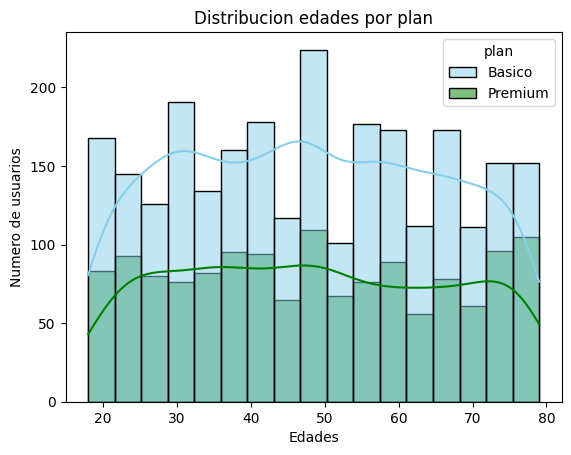

In [32]:
# Histograma para visualizar la edad (age)
sns.histplot(data= user_profile, x= "age" ,hue='plan', palette=['skyblue','green'], kde=True)
plt.xlabel("Edades")
plt.ylabel("Numero de usuarios")
plt.title("Distribucion edades por plan")
plt.show()

💡Insights: 
- Distribucion simetrica donde no se evidencia una distincion clara entre los diferentes grupos de edades, lo que sugiere que no hay alta distincion entre poblacion joven, adulta y mediana edad o adultos mayores para ninguno de los dos planes, se destaca un pico importante de usuarios totales alrededor de la franja de los 50 años, donde se alcanza el conteo más alto

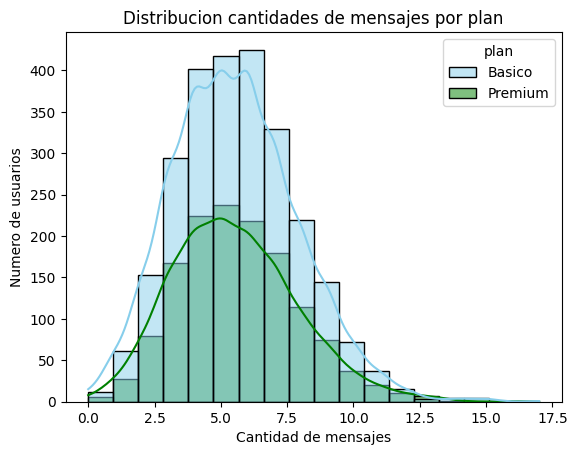

In [33]:

# Histograma para visualizar la cant_mensajes
sns.histplot(data= user_profile, bins= 18, x= "cant_mensajes" ,hue='plan', palette=['skyblue','green'], kde=True)
plt.xlabel("Cantidad de mensajes")
plt.ylabel("Numero de usuarios")
plt.title("Distribucion cantidades de mensajes por plan")

plt.show()

💡Insights: 
- Se evidenicia una distribucion normal con cierto sesgo hacia la derecha con valores posibles, lo que sugiere que un grupo pequeño de clientes tienden a usar en mayor cantidad los mensajes para la comunicación.
- El plan Premium presenta una mayor frecuencia en los rangos centrales, mientras que el plan Básico mantiene una presencia constante

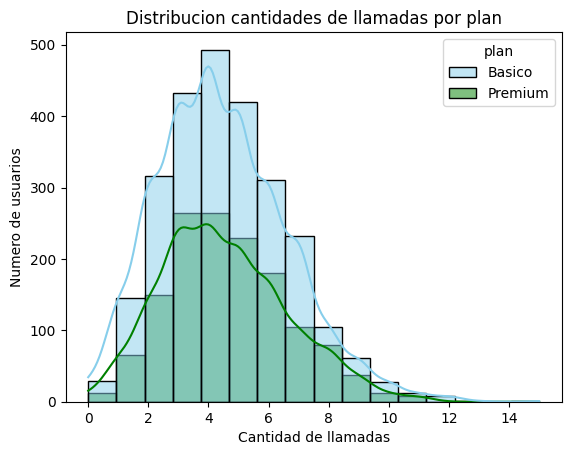

In [34]:
# Histograma para visualizar la cant_llamadas

sns.histplot(data= user_profile, bins= 16, x= "cant_llamadas" ,hue='plan', palette=['skyblue','green'], kde=True)
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Numero de usuarios")
plt.title("Distribucion cantidades de llamadas por plan")
plt.show()


💡Insights: 
- Distribución normal con cierto sesgo hacia la derecha con comportamiento similar a la de mensajes por plan, con un rango maximo menor
- El plan Premium tiene una participación predominante en los picos centrales entre 3 y 5 llamadas, mientras que el plan Básico lo acompaña de manera proporcional.

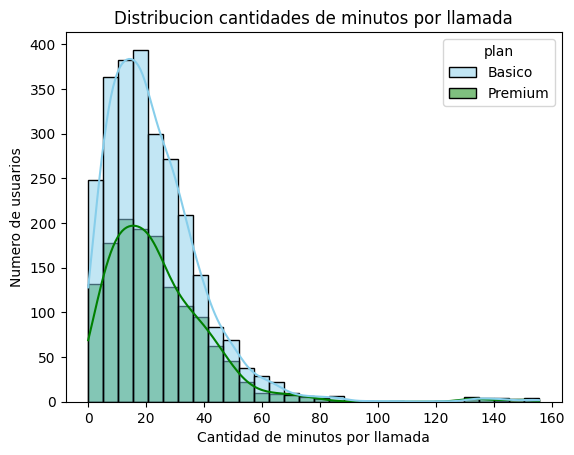

In [35]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data= user_profile, bins=30 ,x= "cant_minutos_llamada" ,hue='plan', palette=['skyblue','green'], kde=True)
plt.xlabel("Cantidad de minutos por llamada")
plt.ylabel("Numero de usuarios")
plt.title("Distribucion cantidades de minutos por llamada")
plt.show()

💡Insights: 
- Tiene una distribucion normal sesgada a la derecha con una concentración entre los 5 y 20 minutos
- Las curvas de tendencia evidencian que el comportamiento es proporcionalmente casi idéntico para el plan Básico y Premium

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

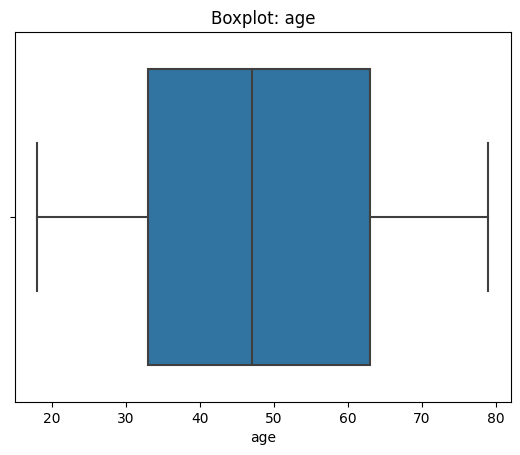

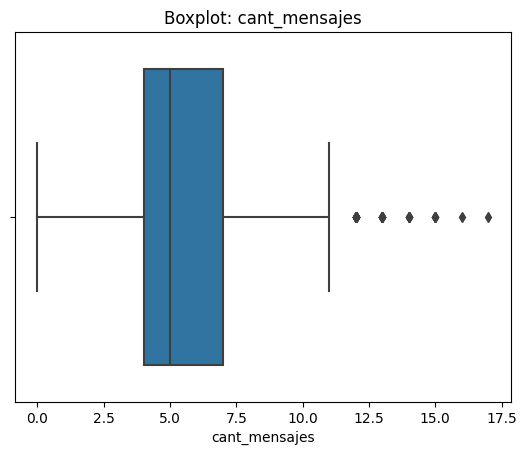

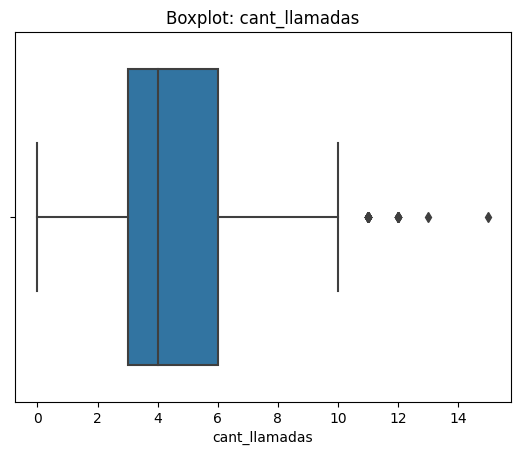

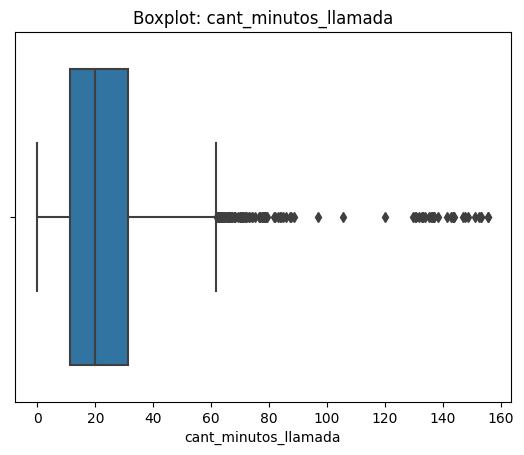

In [36]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data= user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: No presenta outliers
- cant_mensajes: Presenta ciertos outliers que son posibles, con la mediana con cierta tendencia hacia la izquierda del rango intercuartilico, mostrando el sesgo.
- cant_llamadas: Se presentan ciertos outliers mostrando un comportamiento similiar a la cantidad de mensajes.
- cant_minutos_llamada: Se indentifican gran cantidad de outliers hacia la derecha.

In [37]:
# Calcular límites con el método IQR

columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    upper= Q3 + 1.5 * IQR
    print(f'Fila: {col}\nQ1: {Q1}\nQ3: {Q3}\nIQR:{IQR} \nLimite inferior:{upper} \n')


Fila: cant_mensajes
Q1: 4.0
Q3: 7.0
IQR:3.0 
Limite inferior:11.5 

Fila: cant_llamadas
Q1: 3.0
Q3: 6.0
IQR:3.0 
Limite inferior:10.5 

Fila: cant_minutos_llamada
Q1: 11.12
Q3: 31.415
IQR:20.295 
Limite inferior:61.8575 



In [38]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: se deben mantener los outliers pues representan un comportamiento real donde una persona puede mandar 17 mensajes en un año.
- cant_llamadas: se concluye mantener los outliers pues presenta un comportamiento similar al de mensajes, donde la cantidad maxima es posible y no esta tan alejado del limite superior.
- cant_minutos_llamada: Se decide manetener los outliers apesar de que la diferencia entre el valor maximo y el limite superior es mayor, puede seguir representando la realidad

Es importante realizar una segmentacion de esos usuarios que tienen una cantidad de mensajes,  llamadasa y duracion mayor de lo normal

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [42]:
# Crear columna grupo_uso
def classify_segment_usage(row):
    llamadas = row['cant_llamadas']
    mensajes = row['cant_mensajes']

        # Manejo de valores nulos/faltantes
    if pd.isna(llamadas) or pd.isna(mensajes):
        return "Error en Datos"
        
    if llamadas < 5 and mensajes < 5:
        return "Bajo uso"
    elif llamadas < 10 and mensajes < 10:
        return "Uso medio"
    else:
        return "Alto uso"
user_profile["grupo_uso"]= user_profile.apply(classify_segment_usage, axis=1)

In [44]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [45]:
# Crear columna grupo_edad
def classify_segment_age(row):
    edad = row['age']
    
        # Manejo de valores nulos/faltantes
    if pd.isna(edad):
        return "Error en Datos"
        
    if edad < 30:
        return "Joven"
    elif edad < 60:
        return "Adulto"
    else:
        return "Adulto Mayor"
user_profile["grupo_edad"]= user_profile.apply(classify_segment_age, axis=1)

In [47]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7,3,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5,10,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5,2,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11,3,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4,3,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

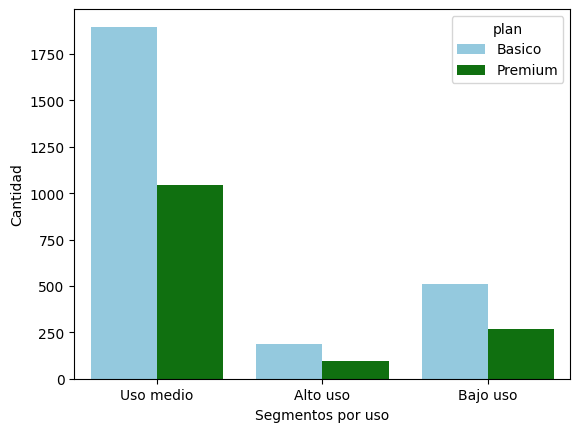

In [48]:
# Visualización de los segmentos por uso

sns.countplot(data= user_profile, x='grupo_uso', hue= 'plan',palette= ['skyblue','green'])
plt.xlabel('Segmentos por uso')
plt.ylabel('Cantidad')
plt.show()


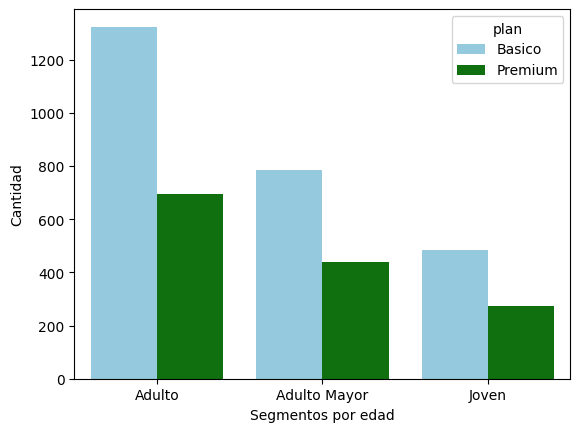

In [52]:
# Visualización de los segmentos por edad

sns.countplot(data= user_profile, x='grupo_edad', hue= 'plan',palette= ['skyblue','green'])
plt.xlabel('Segmentos por edad')
plt.ylabel('Cantidad')
plt.show()


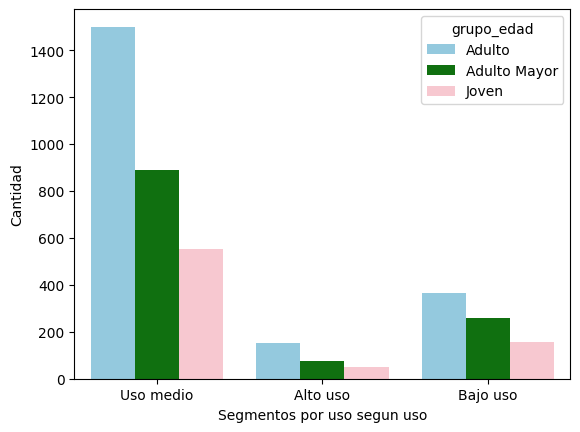

In [53]:
sns.countplot(data= user_profile, x='grupo_uso', hue= 'grupo_edad',palette= ['skyblue','green', 'pink'])
plt.xlabel('Segmentos por uso segun uso')
plt.ylabel('Cantidad')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


El formato de las fechas no estaba dado correctamente, por tanto se genero un ajuste para estos datos, ademas se encontraron fechas superiores a 2024.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

Originalmente los datos presentaban problemas con datos faltantes en columnas relevantes para el analisis como en duration, length dado por la misma naturaleza de la recoleccion de datos. En churn_date y city con una proporcion de 88,35% y 11.72%, ademas presentaron valores invalidos como ? en city y -999 en age. 

Se clasificaron las edades entre "Joven"; menores de 30 años, "Adulto"; entre los 30 y 50 y "Adulto Mayor"; mayores de los 50 años. y en tema de nivel de uso, se clacificaron los clientes entre 'Bajo uso' cuando las llamadas y mensajes son menores de 5, 'Uso medio' cuando llamadas y mensajes estan entre 5 a 10 y 'Alto uso' para el resto de casos. Mediante el analisis, se identifica existen mas usuarios con un uso medio para los dos tipos de planes, seguido de un uso bajo para los dos planes, donde los adultos tienen mayor concentración en este nivel de uso, seguido del Adulto Mayor.

Basamdose en estos datos, el segmento mas valioso para ConnectaTel seria los adultos entre los 30 y 50 años que tienen un uso medio, que es donde estan agrupados la mayoria de usuarios.
Existe cierto grupo de usuarios que tienen a superar los 60min de llamada o mas de 15 mensajes y llamadas realizados al año, por tanto, es importante identificar este tipo de usuarios y determinar el ingreso que estos generan para establecer planes basados en este consumo.

Al momento, basado en la cantidad de usuarios en cada uno de estos segmentos, se recomienda generar planes donde se tenga la combinacion de minutos y llamadas entre los 5 y 10 captando la mayoria de usuarios, ademas de evaluar el impacto que estos usuarios fuera estandar, generando un plan especial para captar este tipo de usuarios.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Valores nulos pra churn_date con proporcion del 88.35% con 3534 nulos
- Valores nulos para city con proporcion del 11.72% con 469 nulos
- Valores nulos para date con una proporcion del 0.125% con solo 50 nulos
- Valores nulos para duration del 55.19% en proporcion, con 22076 valores
- Valores nulos para duration del 44.74 % en proporcion con 17896 valores.
- Valores invalidos para age con valores -999
- Valores invalidos para city con ?
- Formato invalido de fecha para date, reg_date y churn_date

🔍 **Segmentos por Edad**
- Los usuarios que mas usan los servicios son los Jovenes, entre los 30 y 50 años para los dos tipos de plan.
- Los usuarios jovenes menores de 30 años, son los que menos usan los servicios independiente del plan.
  
📊 **Segmentos por Nivel de Uso**
- Los usuarios tiene en general un uso medio de los servicios de telefonia.
- Los usuarios con un uso bajo son el siguiente grupo con mayor cantidad.


➡️ Esto sugiere que el segmento con mayor concentracion de usuarios son los Adultos con uso medio de los servicios.


💡 **Recomendaciones**
- Enforcar esfuerzos de marketing y arreglo de planes para usuarios Adultos con un uso medio de las llamadas y mensajes.
- Revisar impacto en ingresos de los clientes por fuera del estandar, con cantidad de llamadas superiores a 15 y mesajes superiores a 15 o la duración de llamadas superior a 60min

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`